# Implementation of MCP Neuron for AND and OR Function.

MCP Neuron: It’s the first mathematical model of a brain neuron.

Input -> CAlc -> Descision -> output( 0 or 1)

In [1]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  sum_X = [x1 + x2 for x1, x2 in zip(X1, X2)]
  state_neuron = []
  for s in sum_X:
    if s >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  return state_neuron

In [2]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


## Understanding this Notebook: A Beginner's Guide

This notebook walks through some fundamental concepts in artificial intelligence and machine learning, starting with simple neurons and moving towards a basic image classification task.

Let's break it down section by section.

### Section 1: The McCulloch-Pitts (MCP) Neuron for AND and OR Logic

Before diving into complex neural networks, it's helpful to understand the very basic building block: the **McCulloch-Pitts (MCP) Neuron**. This is a simplified model of a biological neuron.

*   **How it Works:** An MCP neuron takes several inputs (usually 0s or 1s), multiplies them by weights (which we'll simplify here), sums them up, and then compares this sum to a `threshold (T)`. If the sum is greater than or equal to the threshold, the neuron 'fires' (outputs a 1); otherwise, it doesn't (outputs a 0).

*   **AND Gate (`MCP_Neurons_AND` function):**
    *   We created a function `MCP_Neurons_AND` that takes two inputs (`X1`, `X2`) and a `threshold (T)`.
    *   For an AND gate, the output should only be 1 if *both* inputs are 1. We found that setting the `T` to 2 achieved this, as `1+1=2`, and `2 >= 2` is true. Any other combination (`0+0`, `0+1`, `1+0`) results in a sum less than 2, leading to an output of 0.

*   **OR Gate (`MCP_Neurons_OR` function):**
    *   Similarly, the `MCP_Neurons_OR` function simulates an OR gate. For an OR gate, the output should be 1 if *at least one* input is 1.
    *   Setting the `T` to 1 works here. If either input is 1 (or both), the sum will be 1 or 2, both of which are `>= 1`, resulting in an output of 1. Only `0+0` will result in 0.

### Section 2: Perceptron for 0 vs. 1 Classification (MNIST Dataset)

Now we apply a slightly more advanced concept, the **Perceptron**, to classify handwritten digits. The perceptron is one of the simplest types of artificial neural networks, capable of learning to classify linearly separable data.

#### Step 1: Load the Dataset

*   We loaded a special dataset called **MNIST**, which contains images of handwritten digits. For this part, we only focused on images of the digits `0` and `1`.
*   Each image is made up of 784 pixels (28x28 pixels). We stored these pixel values in `X` (our features or input data) and the actual digit (0 or 1) in `y` (our labels or correct answers).
*   We also *mounted Google Drive* to access the CSV file containing the dataset.

#### Step 2: Viewing the Dataset

*   We displayed a few example images of `0`s and `1`s to visually inspect our data. This helps us understand what the perceptron will be 'seeing'.

#### Step 3: Initializing Weights and Bias

*   **Weights (`weights`):** These are like the 'importance' values assigned to each pixel. If a pixel is important for identifying a '0', its corresponding weight will adjust during learning.
*   **Bias (`bias`):** This is an extra value that helps the perceptron make decisions, like a baseline adjustment.
*   We started with all `weights` at zero and `bias` at zero. The perceptron will learn the correct values.
*   **Learning Rate (`learning_rate`):** This controls how much the `weights` and `bias` change with each mistake. A smaller rate means slower, more careful learning.
*   **Epochs (`epochs`):** This is the number of times the perceptron will go through the *entire* dataset to learn.

#### Step 4: Make a Decision Function

*   The `decision_function` is the 'brain' of our perceptron. It takes the pixel values (`X`), the current `weights`, and `bias`, and calculates a score.
*   This score is then passed through a **step function**: if the score is `0` or positive, it predicts `1`; otherwise, it predicts `0`. This is how the perceptron makes its binary (yes/no, 0/1) decision.

#### Step 5: Implement the Perceptron Learning Algorithm (Training)

*   The `train_perceptron` function is where the actual learning happens.
*   It iterates over the dataset multiple times (`epochs`). In each iteration:
    1.  It takes an image and its true label.
    2.  It uses the `decision_function` to make a prediction.
    3.  It calculates the `error` by comparing the prediction to the true label.
    4.  **Crucially:** If there's an error, it *adjusts* the `weights` and `bias` slightly, using the `learning_rate`, to make a better prediction next time.
*   After training, it tells us the `accuracy`, which is the percentage of correctly classified images.

#### Step 6: Training the Perceptron and Evaluating Accuracy

*   We called `train_perceptron` with our data and initial parameters. The function returned the learned `weights`, `bias`, and the final `accuracy`.
*   For the 0 vs. 1 dataset, the perceptron achieved `100% accuracy`, meaning it correctly identified every single 0 and 1 in this dataset!

### Step 7: Visualize Misclassified Images (0 vs. 1)

*   This step is normally used to see *which* images the perceptron got wrong.
*   However, since our accuracy was 100%, there were no misclassified images, so the notebook just confirms that all images were correctly classified.

### Section 3: Perceptron for 3 vs. 5 Classification (MNIST Dataset)

Here, we repeat the process, but with a slightly more challenging classification task: distinguishing between handwritten digits `3` and `5`.

#### Load Dataset & Viewing the Dataset

*   We loaded a new subset of the MNIST dataset, this time containing images of `3`s and `5`s.
*   **Important Transformation:** Our perceptron is designed to output `0` or `1`. So, we had to **re-label** the `3`s in the dataset to `0` and the `5`s to `1`. This is a common practice to adapt data to a model's expected input/output format.
*   Again, we viewed some sample images of the re-labeled 3s (now 0) and 5s (now 1).

#### Initialize Weights & Training the Perceptron

*   We re-initialized the `weights` and `bias` to zero for this new task, just like before.
*   Then, we trained the perceptron using the *same* `train_perceptron` function. The perceptron is robust enough to learn different patterns.
*   **Accuracy:** This time, the accuracy was around `98.7%`. This is still very good, but not perfect like the 0 vs. 1 classification. This suggests that 3s and 5s might be a bit harder to distinguish for a simple perceptron.

#### Visualize Misclassified Images

*   Since the accuracy was not 100%, we now *do* have misclassified images!
*   The code identifies these images and displays them. For each misclassified image, it shows what the perceptron `Pred`icted and what the `True` label was. This helps us understand the types of errors the perceptron made (e.g., mistaking a '5' for a '3').

### Conclusion

This notebook demonstrates a journey from the very basic logic gates implemented with an MCP neuron to a simple image classification task using a Perceptron. You've seen how to:

*   Model simple logic.
*   Load and prepare a dataset.
*   Initialize model parameters (weights, bias).
*   Define a decision-making process.
*   Train a model to learn from data.
*   Evaluate its performance.
*   And even peek into its mistakes!

This is a foundational stepping stone to understanding more complex machine learning models.

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    sum_X = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = []
    for s in sum_X:
      if s >= T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)

    return state_neuron

In [4]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week 3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

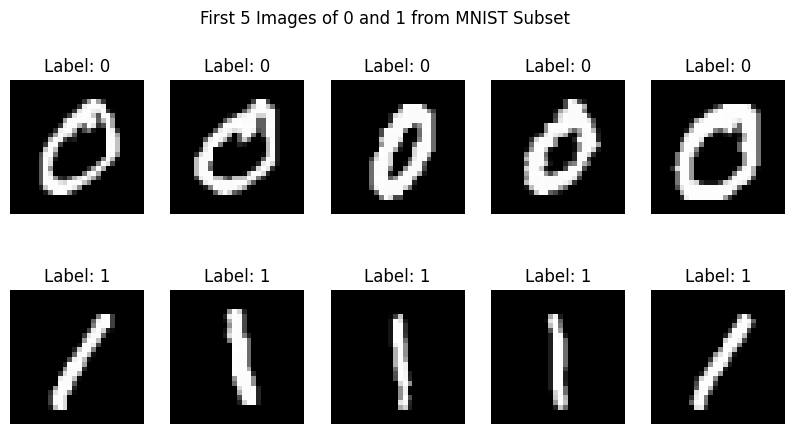

In [7]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [8]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [13]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    # For a perceptron, we often use a step function.
    # If the prediction is greater than or equal to 0, we classify it as 1.
    # Otherwise, we classify it as 0.
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [14]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    n_samples = X.shape[0]

    for epoch in range(epochs):
        correct_predictions = 0
        for i in range(n_samples):
            # Select a single data point and its label
            xi = X[i]
            yi = y[i]

            # Make a prediction using the decision function
            # The decision_function expects X, weights, bias
            y_pred = decision_function(xi.reshape(1, -1), weights, bias)[0] # Reshape xi for single sample prediction

            # Calculate the error
            error = yi - y_pred

            # Update weights and bias only if there's a misclassification
            if error != 0:
                weights += learning_rate * error * xi
                bias += learning_rate * error

            # Count correct predictions for accuracy calculation
            if error == 0:
                correct_predictions += 1

    # After training, calculate the final accuracy
    final_predictions = decision_function(X, weights, bias)
    accuracy = np.mean(final_predictions == y)

    return weights, bias, accuracy

## Training the Perceptron

In [15]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [16]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# Implementation for 3 and 5 Classification.



## Load Dataset

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week 3/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y_original = df_0_1["label"].values  # Store original labels for potential later use

# Convert labels 3 to 0 and 5 to 1 for perceptron training
y = np.where(y_original == 3, 0, 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Unique labels in transformed y:", np.unique(y))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Unique labels in transformed y: [0 1]


## Viewing the dataset

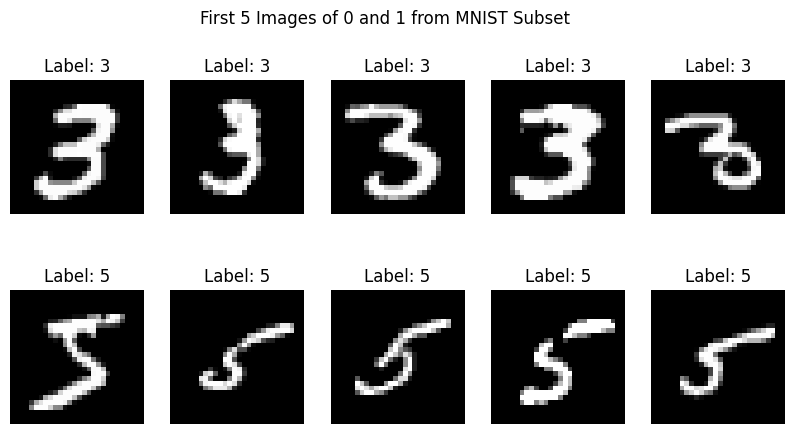

In [20]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 5
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Initialize Weights

In [23]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Training the Perceptron


In [24]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.986866107260124


## Visualize Misclassified Images

Final Accuracy: 0.9869


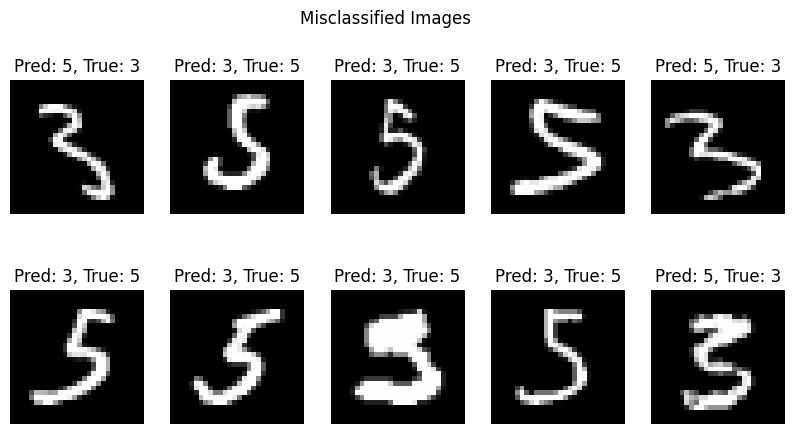

In [26]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        # Map predicted 0/1 back to original 3/5 for display
        predicted_original = 3 if y_pred[idx] == 0 else 5
        # Use y_original for the true label
        true_original = y_original[idx]

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {predicted_original}, True: {true_original}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

### Topics to Learn for Understanding and Explaining this Notebook:

Since you're comfortable with Python, we'll build on that foundation to cover the essential AI/ML concepts presented here. Think of these as building blocks:

---

#### 1. Fundamental Python for Data Science

Even though you know Python, specific libraries are crucial here:

*   **NumPy:** This is the bedrock for numerical computing in Python. We use it extensively for array operations (like `np.zeros`, `np.dot`, `np.where`). Understanding how `numpy` arrays work (their shapes, how to perform element-wise operations, and matrix multiplication with `np.dot`) is fundamental.
*   **Pandas:** Used for loading and manipulating data, especially from CSV files. You should know how to:
    *   `pd.read_csv()`: Load data.
    *   `DataFrame` basics: What a DataFrame is, how to select columns (`df.drop(columns=[...])`), and access values (`.values`).
*   **Matplotlib (and optionally Seaborn):** Essential for visualizing data and model results. Key concepts include:
    *   `plt.subplots()`: Creating figures with multiple plots.
    *   `imshow()`: Displaying images (like the MNIST digits).
    *   `set_title()`, `axis('off')`: Customizing plots.
    *   `plt.show()`: Displaying the plot.

#### 2. The McCulloch-Pitts (MCP) Neuron: The Simplest Model

This is where basic AI concepts begin:

*   **What is a Neuron (Simplified):** Understand it as a unit that takes inputs, processes them, and produces an output.
*   **Binary Inputs/Outputs:** The idea that inputs and outputs are typically 0s or 1s in this simple model.
*   **Summation and Threshold:** How inputs are combined (summed) and compared against a fixed `threshold` to decide the output.
*   **Activation Function (Step Function):** The rule that determines the output based on the sum and threshold (e.g., if sum >= threshold, output 1, else 0).
*   **Logic Gates (AND, OR):** How a simple MCP neuron can simulate basic logic like an AND gate (both inputs must be 1 for output 1) or an OR gate (at least one input is 1 for output 1). Understand how changing the `threshold` changes the logic.

#### 3. The Perceptron: A Learning Neuron

This is an extension of the MCP neuron, now with the ability to *learn*:

*   **Introduction to Machine Learning:** What it means for a computer to 'learn' from data without explicit programming for every scenario.
*   **Supervised Learning:** The concept that the model learns from *labeled examples* (input images and their correct digit labels).
*   **Weights and Bias:** These are the learnable parameters of the perceptron. Understand that:
    *   **Weights:** Determine the 'importance' of each input (pixel). High weight means that pixel strongly influences the decision.
    *   **Bias:** An additional adjustable value that helps the neuron make a decision, acting like an offset.
*   **Decision Function:** How the perceptron makes a prediction:
    *   It calculates a **weighted sum** of its inputs (each input multiplied by its weight, plus the bias).
    *   This sum is then passed through an **activation function** (again, a step function in our case) to produce a binary output (0 or 1).
*   **Perceptron Learning Algorithm:** This is the core of how it learns:
    *   **Error Calculation:** How the model compares its `prediction` to the `true label` to find out if it made a mistake.
    *   **Weight/Bias Update:** If there's an error, the `weights` and `bias` are adjusted slightly. The goal is to make the model predict correctly the next time it sees that input.
    *   **Learning Rate:** Controls how big these adjustments are. A small learning rate means slower, more cautious learning.
    *   **Epochs:** One full pass through the entire training dataset. The model learns over many epochs.
*   **Accuracy:** How we measure how well the perceptron performs (percentage of correct predictions).
*   **Linear Separability:** The idea that a single perceptron can only classify data that can be separated by a straight line (or hyperplane in higher dimensions). This explains why it works perfectly for 0s and 1s but might struggle slightly more with 3s and 5s (which are visually more similar and less linearly separable).

#### 4. Data Handling for Machine Learning

*   **Dataset (MNIST):** What the MNIST dataset is (handwritten digits) and why it's a common 'hello world' for image classification.
*   **Features (X) and Labels (y):** Understanding the input data (pixels of the image) as 'features' and the correct answer (the digit) as 'labels'.
*   **Data Preprocessing/Transformation:** The crucial step of preparing data for the model. Specifically, how we **re-labeled** the '3's to '0' and '5's to '1' because our simple perceptron is designed for binary (0/1) classification.

By focusing on these topics, especially the purpose of weights, bias, the decision function, and how the learning algorithm adjusts them based on errors, you'll be well-equipped to explain this notebook's content. Don't worry about memorizing every line of code; focus on understanding *why* each part exists and *what* it accomplishes in the overall process of a neuron learning to classify!